<a href="https://colab.research.google.com/github/hye-lily/in-summer/blob/main/01_kwic_exploration%E3%85%A1%EC%82%AC%ED%9A%8C%EC%96%B8%EC%96%B4%ED%95%99_%EC%96%B4%ED%9C%98%EB%B6%84%EC%84%9D_ipynb%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1차시 — 코퍼스 탐색과 KWIC 복습

**자료**: 국립국어원 웹말뭉치 추출본 EXNE2105170015 (개체명 분석 주석)

**학습 목표**
1. NE(개체명) 주석이 달린 JSON 말뭉치를 파이썬으로 평탄화한다.
2. 일반 텍스트 KWIC과 **NE 라벨 기반 KWIC** 두 방식을 비교한다.
3. 빈도(1층)와 분산(2층) 시각화로 코퍼스의 의미적 윤곽을 잡는다.

**연구 질문**
> 한국어 블로그 코퍼스에서 음식(CV_FOOD)·인물(PS_NAME) 같은 개체명은 어떻게 분포하며, 어떤 문맥에서 등장하는가?

---

## 0. 환경 설정 (한글 폰트)
import as -> as soon as possible 을 asap로 하는 것과 같은 방식

In [1]:
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
mpl.rc('axes', unicode_minus=False)
print('한글 폰트 설정 완료.')

한글 폰트 설정 완료.


## 1. 코퍼스 불러오기

구글 드라이브에 JSON 파일을 올린 뒤 마운트합니다.  
(자료 파일명 예: `EXNE2105170015.json`)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json

# 자기 드라이브 경로에 맞게 수정-> 아래 결과가 스케닝이 잘 됐는지 보여줌.
FILE_PATH = '/content/drive/MyDrive/EXNE2105170015.json'

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print('코퍼스 메타데이터:')
print(json.dumps(data['metadata'], ensure_ascii=False, indent=2))
print(f"\n문서 수: {len(data['document'])}")

코퍼스 메타데이터:
{
  "title": "국립국어원 웹말뭉치 추출 EBXX1900-17",
  "creator": "국립국어원",
  "distributor": "국립국어원",
  "year": "2020",
  "category": "웹말뭉치>구축",
  "annotation_level": "개체명 분석",
  "sampling": "부분 추출 - 임의 추출"
}

문서 수: 281


### 1.1 데이터 구조 한 번 들여다보기

한 문서는 `metadata` + `sentence` 리스트로 구성되고, 각 문장은 `form`(원문) + `word`(어절) + `NE`(개체명) 세 키를 가집니다.

In [ ]:
for doc in data['document']:        # 문서들을 하나씩 봄
    for s in doc['sentence']:       # 그 문서 안의 문장들을 하나씩 봄
        if s.get('NE'):             # NE(개체명)가 있으면-if 문 중요함 if else 같이 등장함 개채를 찾을 때까지 찾으면 출력해
            print(...)              # 출력하고
            break                   # 안쪽 for문 멈춤
    else:
        continue                    # NE 없는 문서면 다음 문서로
    break                           # 바깥 for문도 멈춤 (하나만 찾으면 끝)

Ellipsis


**NE 라벨 체계** — 첫 두 글자가 대분류입니다.
- `PS_`: 사람 (PS_NAME, PS_CHARACTER, ...)
- `LC_`, `LCP_`: 장소 (LCP_COUNTRY, LCP_COUNTY, ...)
- `OG_`, `OGG_`: 조직 (OGG_ECONOMY, OGG_FOOD, ...)
- `CV_`: 문명/문화 (CV_FOOD, CV_DRINK, CV_OCCUPATION, ...)
- `DT_`, `TI_`: 날짜·시간
- `QT_`: 수량 (QT_COUNT, QT_PRICE, QT_AGE, ...)
- `AM_`: 동·식물/신체부위
- `AFW_`: 인공물
- `TM_`, `TMI_`: 용어/약어

### 1.2 문장 단위 DataFrame으로 평탄화
pandas는 파이썬에서 표 형태의 데이터를 다루는 라이브러리
엑셀이나 SPSS 같은 표 데이터를 파이썬에서 다루게 해주는 도구
핵심 객체가 DataFrame — 행과 열로 이루어진 표
관례적으로 import pandas as pd로 줄여서 부름

In [4]:
import pandas as pd                                          # pandas 라이브러리 불러옴 (표 데이터 다루는 도구)


def flatten_corpus(data):                                    # 함수 정의: data를 받아서 처리
    """문서-문장 구조를 문장 단위 DataFrame으로 변환.
    NE 정보는 리스트 컬럼으로 보존한다.
    """                                                      # 함수 설명문 (실행에는 영향 없음)
    rows = []                                                # 빈 리스트 생성 (여기에 행들을 쌓을 예정)
    for doc in data['document']:                             # 문서를 하나씩 꺼냄
        meta = doc['metadata']                               # 그 문서의 메타데이터 저장
        for sent in doc['sentence']:                         # 문서 안의 문장을 하나씩 꺼냄
            ne_list = sent.get('NE', [])                     # 그 문장의 개체명 리스트 (없으면 빈 리스트)
            rows.append({                                    # 표의 한 행(row)을 딕셔너리로 추가
                'doc_id': doc['id'],                         # 문서 ID
                'sent_id': sent['id'],                       # 문장 ID
                'form': sent['form'],                        # 문장 원문
                'ne_forms':  [n['form']  for n in ne_list],  # 개체명 표현 리스트 (예: ['공나형'])
                'ne_labels': [n['label'] for n in ne_list],  # 개체명 라벨 리스트 (예: ['PS'])
                'ne_spans':  [(n['begin'], n['end']) for n in ne_list],  # 개체명 위치 (시작-끝)
                'title': meta.get('title'),                  # 문서 제목
                'publisher': meta.get('publisher'),          # 발행처
                'date': meta.get('date'),                    # 발행일
                'year': (meta.get('date') or '')[:4],        # 발행 연도만 추출 (앞 4글자)
            })
    return pd.DataFrame(rows)                                # 쌓은 rows를 DataFrame(표)으로 변환해 반환

In [6]:
df = flatten_corpus(data)
df.head()           # 표 미리보기-> df 는 앞에 정의가 무조건 미리 있어야함
df.columns          # 어떤 컬럼이 있는지 확인
df.shape            # (행 수, 열 수)

(16055, 10)

In [8]:
print(df.shape)
print(df.columns)
df.head()           # head는 맨 끝에 두면 표로 나옴 / doc id는 280개 문서에 각각 이름이 붙음 것 / 각괄호두개[]는 없다는 뜻임


(16055, 10)
Index(['doc_id', 'sent_id', 'form', 'ne_forms', 'ne_labels', 'ne_spans',
       'title', 'publisher', 'date', 'year'],
      dtype='object')


,doc_id,sent_id,form,ne_forms,ne_labels,ne_spans,title,publisher,date,year
0,EBRW1903002754.81,EBRW1903002754.81.1.1,갑자기 사진첩을 정리하다가.,[],[],[],10년전.. 추억은 아름답다..,egloos,20070109,2007
1,EBRW1903002754.81,EBRW1903002754.81.2.1,생각난..,[],[],[],10년전.. 추억은 아름답다..,egloos,20070109,2007
2,EBRW1903002754.81,EBRW1903002754.81.3.1,과거 여행의 기록,[],[],[],10년전.. 추억은 아름답다..,egloos,20070109,2007
3,EBRW1903002754.81,EBRW1903002754.81.4.1,역시 사진이 남긴 하는것이구나..,[],[],[],10년전.. 추억은 아름답다..,egloos,20070109,2007
4,EBRW1903002754.81,EBRW1903002754.81.5.1,25살 딱 10년전...,"[25살, 10년전]","[QT_AGE, DT_OTHERS]","[(0, 3), (6, 10)]",10년전.. 추억은 아름답다..,egloos,20070109,2007


In [ ]:
print("전체 행(문장) 수:", len(df))
print("문서 수:", len(df.drop_duplicates('doc_id')))

전체 행(문장) 수: 16055
문서 수: 281


**💡 학생 활동 1**  
패들렛 제출: https://padlet.com/primenh/padlet-146w4x7uscxs1lvb
다음을 확인해 보세요.
1. `publisher` 분포 — 어떤 매체에서 가장 많이 추출되었나요?
2. 연도별 문서 수 — 어느 시기에 자료가 집중되어 있나요?
3. NE 라벨 138개 중 상위 15개를 빈도순으로 출력하세요. (힌트: `df['ne_labels'].explode().value_counts()`)

In [ ]:
# 여기에 코드를 작성하세요


In [9]:
# 1. `publisher` 분포 확인 (문서별 중복 제거)
print(df.drop_duplicates('doc_id')['publisher'].value_counts())

# 2. 연도별 문서 수
# 'year' 컬럼이 이미 텍스트로 추출되어 있으므로, 이를 사용하여 연도별 문서 수를 계산합니다.
print('\n연도별 문서 수:')
print(df.drop_duplicates('doc_id')['year'].value_counts().sort_index())

# 3. NE 라벨 138개 중 상위 15개를 빈도순으로 출력
print('\n상위 15개 NE 라벨 빈도:')
print(df['ne_labels'].explode().value_counts().head(15))

publisher
네이버 블로그    266
egloos      15
Name: count, dtype: int64

연도별 문서 수:
year
2006     1
2007     3
2008     3
2009     1
2010     4
2011     5
2012     3
2013     5
2014     9
2015    15
2016    28
2017    48
2018    89
2019    67
Name: count, dtype: int64

상위 15개 NE 라벨 빈도:
ne_labels
CV_FOOD               2519
QT_COUNT               969
PS_NAME                919
AM_PART                619
CV_DRINK               600
OGG_ECONOMY            592
CV_RELATION            569
QT_ORDER               529
PS_CHARACTER           486
OGG_FOOD               452
DT_DAY                 422
AFW_OTHER_PRODUCTS     392
LC_OTHERS              366
DT_DURATION            341
TI_DURATION            329
Name: count, dtype: int64


## 2. 두 가지 KWIC

### 2.1 전통 KWIC — 문자열 검색

AntConc식 KWIC을 정규식으로 직접 구현해 봅시다.

In [10]:
import re                                            # 정규식 라이브러리 (문자열 패턴 매칭)
from IPython.display import HTML                     # 코랩/주피터(코랩이 주피터와 파이썬을 합한 것)에서 HTML 표시용

def kwic_text(df, keyword, window=20, max_rows=20):  # 함수 정의: 데이터, 검색어, 좌우 글자수, 최대 행수
    """문자열/정규식 기반 KWIC."""                    # 함수 설명
    pattern = re.compile(keyword)                    # 검색어를 정규식 패턴으로 변환 (속도↑)-->맛있다'와 같은 표현을 정규식으로 검색할 때 생길 수 있는 문제는 활용형을 놓칠 수 있다->명사 찾을 때는 ㄱㅊ
    results = []                                     # 결과 담을 빈 리스트
    for _, row in df.iterrows():                     # df의 각 행을 하나씩 꺼냄 (_는 인덱스, 안 씀)
        text = row['form']                           # 그 행의 문장 원문을 text에 저장
        for m in pattern.finditer(text):             # text에서 패턴이 나오는 모든 위치를 찾음
            s, e = m.span()                          # 매칭된 부분의 시작(s)·끝(e) 위치
            results.append({                         # 결과 리스트에 한 줄 추가
                'left':  text[max(0, s-window):s],   # 왼쪽 문맥 (앞 20글자, 음수 방지)
                'node':  text[s:e],                  # 매칭된 키워드 자체
                'right': text[e:e+window],           # 오른쪽 문맥 (뒤 20글자)
            })
            if len(results) >= max_rows:             # 최대 행수 도달하면
                return pd.DataFrame(results)         # 표로 만들어 즉시 반환
    return pd.DataFrame(results)                     # 다 돌고 끝나면 결과 반환


def kwic_pretty(kwic_df, node_color='#fff3cd'):      # 결과를 예쁘게 보여주는 함수 (기본 노란색)
    html = '<table style="font-family: monospace; border-collapse: collapse;">'   # 표 시작
    for _, r in kwic_df.iterrows():                  # 각 결과 행을 돌면서
        html += (                                    # HTML 한 줄씩 이어붙임
            f'<tr>'
            f'<td style="text-align:right; padding:2px 8px;">{r.left}</td>'   # 왼쪽: 오른쪽 정렬
            f'<td style="text-align:center; padding:2px 8px; background:{node_color}; font-weight:bold;">{r.node}</td>'   # 가운데: 강조 (노란 배경+굵게)
            f'<td style="text-align:left; padding:2px 8px;">{r.right}</td>'   # 오른쪽: 왼쪽 정렬
            f'</tr>'
        )
    html += '</table>'                               # 표 닫기
    return HTML(html)                                # HTML 객체로 반환 (콜랩에서 렌더링됨)


kwic_pretty(kwic_text(df, r'맛있', window=20, max_rows=15))   # 실행: '맛있' 검색, 좌우 20자, 최대 15줄

생각보다,맛있,고..
딸기양이 많아서 쨈이 꽤,맛있,었다.
려있고 위에는 생과일이 놓여있어 꽤,맛있,었다.
시간도 없고,맛있,는 건 먹고 싶고 동네에서 해결하자는
아래 짬뽕은,맛있,게 먹었다.
ㅜ ㅜ 사이드로 비치는 통밀퐁은,맛있,게 먹었다.
서 기대했는데 기대만큼 놀랄 정도로,맛있,어 뭐 이런 건 아니고 나쁘지 않다.
미용사가 된장라면 끓여먹는게 너무,맛있,어보여서 풀무원 생라면 사다가 비슷하
아무튼 예쁘고,맛있,으니
이 트러플 파스타 너무,맛있,는거 아님
너무,맛있,었는데 거기가서 또 먹고싶어


In [11]:
!pip install konlpy
from konlpy.tag import Okt    # 또는 Kkma, Mecab
okt = Okt()

def kwic_morph(df, target_morph, target_pos, window=20, max_rows=20):
    """형태소 + 품사 기반 KWIC."""
    results = []
    for _, row in df.iterrows():
        text = row['form']
        morphs = okt.pos(text)
        # target_morph가 target_pos로 등장하는지 확인
        for i, (m, p) in enumerate(morphs):
            if m == target_morph and p == target_pos:
                # 좌우 문맥 형태소 추출 / lamma(기본형)과 실현형 중에 뭘로 선택할지 선택해야함.
                left = ' '.join([w for w, _ in morphs[max(0,i-window):i]])
                right = ' '.join([w for w, _ in morphs[i+1:i+1+window]])
                results.append({'left': left, 'node': f'{m}/{p}', 'right': right})
                if len(results) >= max_rows:
                    return pd.DataFrame(results)
    return pd.DataFrame(results)

# 예: '맛있다'의 형용사 어간만 검색
kwic_pretty(kwic_morph(df, '맛있다', 'Adjective', window=5, max_rows=15))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 35.0 MB/s eta 0:00:00


쫄깃쫄깃,맛있다/Adjective,...
,맛있다/Adjective,ㅠㅠ 같이 먹었으면 더 맛있었을거야
배추 를 많이 넣을수록,맛있다/Adjective,
역시 곱창 은 언제 먹어도,맛있다/Adjective,ㅠㅠㅠㅠㅠ
곳 거의 없는데 여기는 최고다,맛있다/Adjective,
특히 저 화이트 아스파라거스 가,맛있다/Adjective,
왕 크니까 왕,맛있다/Adjective,! 조각 이 크게 나있어서
"하고 하나 샀는데 웬걸 ,",맛있다/Adjective,!! 한 개 밖에 사지
아쉽게도,맛있다/Adjective,로 밖에 표현 못 하는
가격 도 비싸지 않고 정말,맛있다/Adjective,.
"볶아 먹어도 , 생으로 먹어도",맛있다/Adjective,.


In [12]:
!pip install kiwipiepy                              # Kiwi 설치 (랩에선 한 번만)
from kiwipiepy import Kiwi                          # Kiwi 클래스 불러옴
kiwi = Kiwi()                                       # 분석기 객체 생성

# 분석 결과 확인
result = kiwi.tokenize("정말 맛있는 김밥이었어요.")
for token in result:
    print(token.form, token.tag)                    # 형태소와 품사 태그 출력

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.6 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=23094364936c66edad0c8ef418ffc930b5886a26542703a924e0729406ddbb34
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model
정말 MAG
맛있 VA
는 ETM
김밥 NNG
이 VCP
었 EP
어요 EF
. SF


In [13]:
import pandas as pd
from IPython.display import HTML

def kwic_kiwi(df, target_form, target_tag, window=5, max_rows=20):
    """Kiwi 형태소 분석 기반 KWIC.
    target_form: 검색할 형태소 (예: '맛있')
    target_tag:  품사 태그 (예: 'VA' = 형용사)
    window: 좌우 형태소 개수
    """
    results = []
    for _, row in df.iterrows():                    # df 각 행을 돌면서
        text = row['form']                          # 문장 원문
        tokens = kiwi.tokenize(text)                # Kiwi로 형태소 분석

        for i, tok in enumerate(tokens):            # 토큰을 하나씩 확인
            # 어간과 품사가 모두 일치하는지 검사
            if tok.form == target_form and tok.tag == target_tag:
                # 좌우 문맥 형태소 추출
                left_tokens  = tokens[max(0, i-window):i]
                right_tokens = tokens[i+1 : i+1+window]

                left_str  = ' '.join([t.form for t in left_tokens])
                right_str = ' '.join([t.form for t in right_tokens])
                node_str  = f'{tok.form}/{tok.tag}'

                results.append({
                    'left':  left_str,
                    'node':  node_str,
                    'right': right_str,
                })

                if len(results) >= max_rows:
                    return pd.DataFrame(results)
    return pd.DataFrame(results)


def kwic_pretty(kwic_df, node_color='#fff3cd'):
    """KWIC 결과를 HTML 표로 예쁘게 출력."""
    html = '<table style="font-family: monospace; border-collapse: collapse;">'
    for _, r in kwic_df.iterrows():
        html += (
            f'<tr>'
            f'<td style="text-align:right; padding:2px 8px;">{r.left}</td>'
            f'<td style="text-align:center; padding:2px 8px; background:{node_color}; font-weight:bold;">{r.node}</td>'
            f'<td style="text-align:left; padding:2px 8px;">{r.right}</td>'
            f'</tr>'
        )
    html += '</table>'
    return HTML(html)

In [ ]:
# '맛있' 어간의 형용사 용법 검색
kwic_pretty(kwic_kiwi(df, '맛있', 'VA', window=5, max_rows=15))

생각 보다,맛있/VA,고 ..
많 어서 쨈 이 꽤,맛있/VA,었 다 .
놓이 어 있 어 꽤,맛있/VA,었 다 .
시간 도 없 고,맛있/VA,는 거 ᆫ 먹 고
아래 짬뽕 은,맛있/VA,게 먹 었 다 .
로 비치 는 통밀퐁 은,맛있/VA,게 먹 었 다 .
만큼 놀라 ᆯ 정도 로,맛있/VA,어 뭐 이런 거 ᆫ
먹 는 것 이 너무,맛있/VA,어 보이 어서 풀무원 생
아무튼 예쁘 고,맛있/VA,으니
이 트러플 파스타 너무,맛있/VA,는 거 아니 ᆷ
너무,맛있/VA,었 는데 거기 가 어서


### 2.2 NE 라벨 기반 KWIC — 의미 단위 검색

전통 KWIC은 "문자열"을 검색하지만, NE 주석을 활용하면 "의미 클래스"로 검색할 수 있습니다. 예를 들어 `CV_FOOD`로 검색하면 어떤 음식 이름이든 모두 잡힙니다.

In [14]:
def kwic_ne(df, target_label, window=20, max_rows=20):     # NE 라벨 기반 KWIC 함수 정의
    """NE 라벨 기반 KWIC. 라벨이 붙은 모든 표현을 노드로 사용."""   # 함수 설명문
    results = []                                            # 결과 담을 빈 리스트
    for _, row in df.iterrows():                            # df의 각 행(문장)을 하나씩 꺼냄
        if target_label not in row['ne_labels']:            # 그 문장에 찾는 라벨 없으면
            continue                                        # 다음 문장으로 건너뜀 (속도↑)
        text = row['form']                                  # 그 문장의 원문 저장
        for label, form, (b, e) in zip(row['ne_labels'],    # 라벨 리스트 +
                                       row['ne_forms'],     # 개체명 표현 리스트 +
                                       row['ne_spans']):    # 위치(시작,끝) 리스트를 짝지어 돌림
            if label != target_label:                       # 라벨이 안 맞으면
                continue                                    # 건너뜀
            results.append({                                # 결과 리스트에 한 줄 추가
                'left':  text[max(0, b-window):b],          # 왼쪽 문맥 (시작 b 앞 20자, 음수 방지)
                'node':  form,                              # 가운데: 개체명 표현 자체
                'right': text[e:e+window],                  # 오른쪽 문맥 (끝 e 뒤 20자)
                'label': label,                             # 라벨 정보도 함께 저장
            })
            if len(results) >= max_rows:                    # 최대 행수 도달하면
                return pd.DataFrame(results)                # 표로 만들어 즉시 반환
    return pd.DataFrame(results)                            # 다 돌고 끝나면 결과 반환


kwic_pretty(                                                # 결과를 예쁘게 HTML로 출력
    kwic_ne(df, 'CV_FOOD', window=20, max_rows=15),         # 실행: 음식 개체명, 좌우 20자, 15줄 **여기에보고싶은것을입력
    node_color='#ffe4b5'                                    # 가운데 강조색 = 살구색
)

그의 멋진 솜씨로,탄두리 치킨,을 구워주기로 했었는데
간동안이나 징하게 끓여 흐믈흐믈하던,닭도리탕,맛을
거기서는,밥,"먹는데 의의가 있었고 곤드레밥, 메"
거기서는 밥 먹는데 의의가 있었고,곤드레밥,", 메밀전병, 감자전을 먹었다."
"밥 먹는데 의의가 있었고 곤드레밥,",메밀전병,", 감자전을 먹었다."
"의의가 있었고 곤드레밥, 메밀전병,",감자전,을 먹었다.
,메밀전병,도 괜찮았지만 난 역시 감자전이..
메밀전병도 괜찮았지만 난 역시,감자전,이..
위의 어두운 사진은,딸기잼,만드는 곳의 실내.
우리는,쨈,"만들고, 저 뒤의 사람들은 치즈를"
"리는 쨈 만들고, 저 뒤의 사람들은",치즈,를 만든다.


**💡 학생 활동 2**  
다음 세 가지를 비교해 보세요.
1. `kwic_text(df, r'맛있')` — 문자열 검색
2. `kwic_ne(df, 'CV_FOOD')` — 음식 NE 검색
3. `kwic_ne(df, 'CV_DRINK')` — 음료 NE 검색

**토론**: 두 방식의 차이는 무엇인가요? '맛있' 같은 평가어 검색에는 어느 쪽이 더 유리하고, '음식 일반'의 분포를 보려면 어느 쪽이 적합한가요?

In [ ]:
# 여기에 코드를 작성하세요


### 1. `kwic_text(df, r'맛있')` — 문자열 검색

In [ ]:
kwic_pretty(kwic_text(df, r'맛있', window=20, max_rows=15))

### 2. `kwic_ne(df, 'CV_FOOD')` — 음식 NE 검색

In [ ]:
kwic_pretty(kwic_ne(df, 'CV_FOOD', window=20, max_rows=15))

### 3. `kwic_ne(df, 'CV_DRINK')` — 음료 NE 검색

In [ ]:
kwic_pretty(kwic_ne(df, 'CV_DRINK', window=20, max_rows=15))

## 3. 다층 시각화 — 1층: NE 라벨 빈도

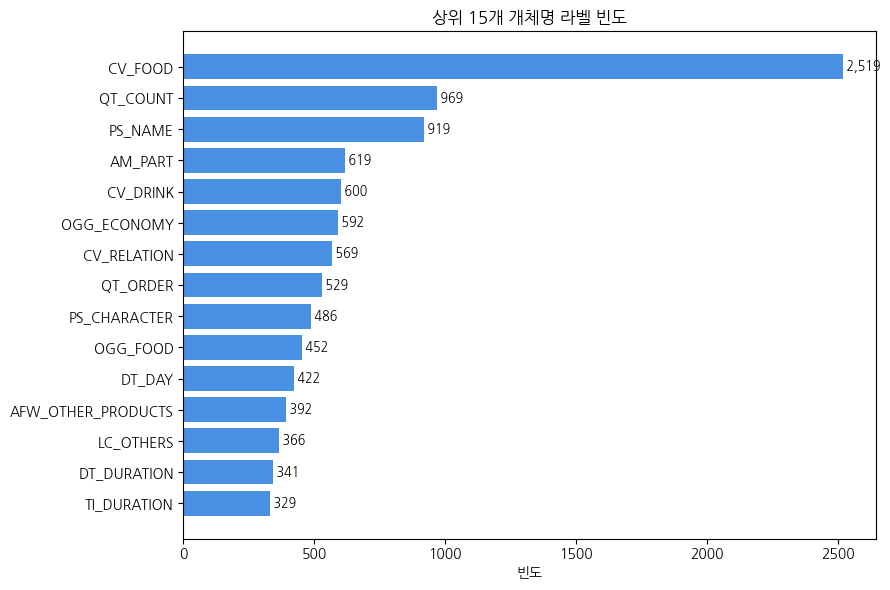

In [15]:
label_counts = df['ne_labels'].explode().value_counts()
top15 = label_counts.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color='#4A90E2')
ax.set_xlabel('빈도')
ax.set_title('상위 15개 개체명 라벨 빈도')
for b, v in zip(bars, top15.values):
    ax.text(v, b.get_y() + b.get_height()/2, f' {v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 3.1 대분류로 묶어서 보기

라벨이 138개로 많으니, `_` 앞 접두사로 묶어 대분류 분포를 봅시다.

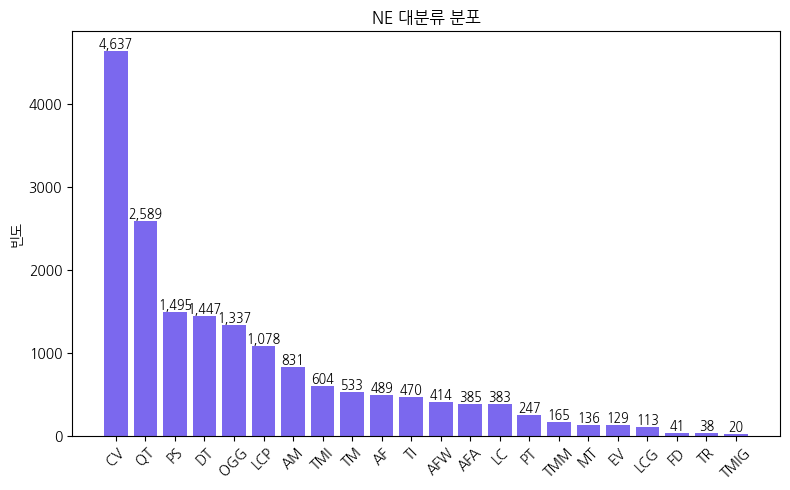

In [16]:
def major_class(label):
    return label.split('_')[0]

major_counts = df['ne_labels'].explode().dropna().map(major_class).value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(major_counts.index, major_counts.values, color='#7B68EE')
ax.set_ylabel('빈도')
ax.set_title('NE 대분류 분포')
for i, v in enumerate(major_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

## 4. 다층 시각화 — 2층: 분산 (Dispersion)

빈도가 비슷해도, 코퍼스 전체에 고루 퍼져 있는 라벨과 특정 문서에 몰려 있는 라벨은 다른 이야기를 합니다
cvfood는 균질하고, ps name은 불균질하다
food 랑 drink  가 같이 가오 있음.

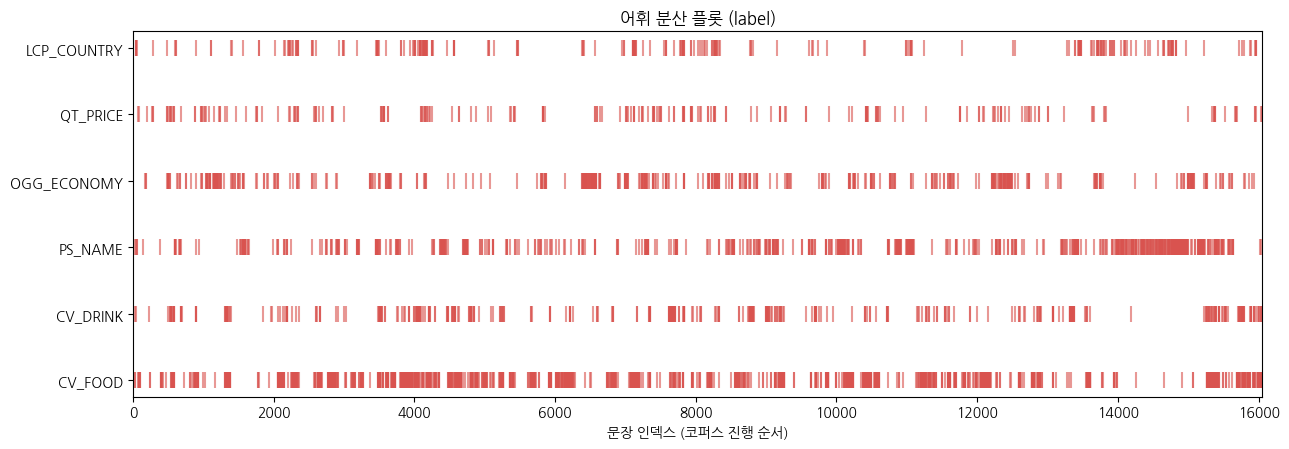

In [17]:
def dispersion_plot(df, targets, mode='label'):
    fig, ax = plt.subplots(figsize=(13, 0.6 * len(targets) + 1))
    n = len(df)
    for i, t in enumerate(targets):
        if mode == 'label':
            hits = df.index[df['ne_labels'].apply(lambda lst: t in lst)].tolist()
        else:
            pat = re.compile(t)
            hits = df.index[df['form'].apply(lambda s: bool(pat.search(s)))].tolist()
        ax.scatter(hits, [i]*len(hits), marker='|', s=120, color='#D9534F', alpha=0.6)
    ax.set_yticks(range(len(targets)))
    ax.set_yticklabels(targets)
    ax.set_xlabel('문장 인덱스 (코퍼스 진행 순서)')
    ax.set_title(f'어휘 분산 플롯 ({mode})')
    ax.set_xlim(0, n)
    plt.tight_layout(); plt.show()

dispersion_plot(df, ['CV_FOOD', 'CV_DRINK', 'PS_NAME', 'OGG_ECONOMY', 'QT_PRICE', 'LCP_COUNTRY'], mode='label')

**💡 토론 질문**
1. `CV_FOOD`는 코퍼스에 고르게 퍼져 있나요, 몰려 있나요? 그 패턴에서 무엇을 추론할 수 있나요?
2. `PS_NAME`(사람 이름)은 어떤 분포를 보이나요? 어느 문서들에 몰려 있을까요?
3. 빈도 1층 그래프와 분산 2층 그래프 중, "이 라벨이 이 코퍼스를 대표하는가"라는 질문에는 어느 쪽이 더 잘 답합니까?

### 4.1 문서별 NE 프로파일 — 코퍼스 내부의 이질성

어떤 문서가 어떤 NE 대분류를 주로 가지는지 보면, 이 블로그 코퍼스 안에 몇 종류의 글이 섞여 있는지(문서 종류)가 드러납니다.

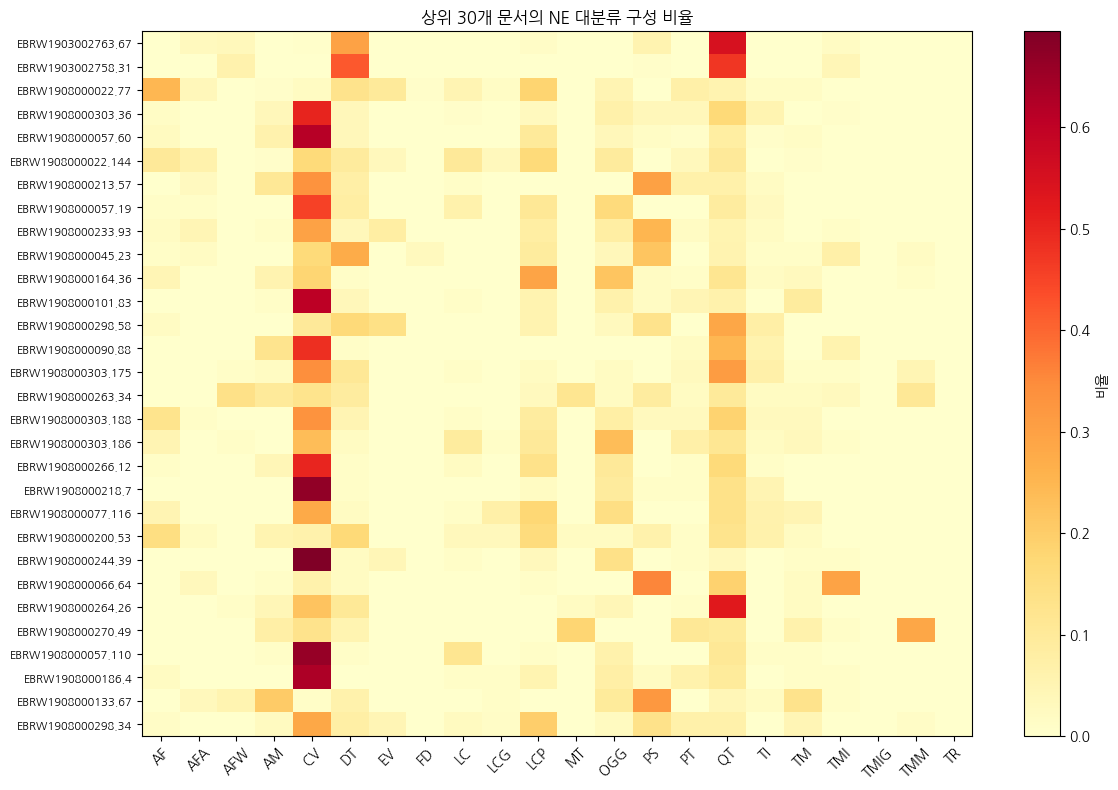

In [18]:
df_exp = df[['doc_id', 'ne_labels']].explode('ne_labels').dropna()
df_exp['major'] = df_exp['ne_labels'].map(major_class)
doc_profile = df_exp.groupby(['doc_id', 'major']).size().unstack(fill_value=0)
doc_profile_norm = doc_profile.div(doc_profile.sum(axis=1), axis=0).fillna(0)

top_docs = doc_profile.sum(axis=1).sort_values(ascending=False).head(30).index
subset = doc_profile_norm.loc[top_docs]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(subset.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(subset.columns)))
ax.set_xticklabels(subset.columns, rotation=45)
ax.set_yticks(range(len(subset.index)))
ax.set_yticklabels([d[:20] for d in subset.index], fontsize=8)
ax.set_title('상위 30개 문서의 NE 대분류 구성 비율')
plt.colorbar(im, ax=ax, label='비율')
plt.tight_layout(); plt.show()

**해석 포인트** — CV 라벨이 압도적인 문서는 음식·맛집 블로그일 가능성이 높고, LC/LCP가 많은 문서는 여행기, PS와 OGG가 많은 문서는 시사·인물 글일 수 있습니다. 이 가설을 다음 차시에서 클러스터링으로 확인합니다.